<a href="https://colab.research.google.com/github/AlekAbrams/ann_traffic_final_project/blob/main/ANN_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("Traffic_Volume_Counts_20251111.csv")

# Remove commas and convert all hourly traffic columns to numeric
hourly_cols = [col for col in df.columns if ":" in col]

# Replace weird values with NaN
df[hourly_cols] = df[hourly_cols].replace(
    ["", " ", "-", "–", ".", "N/A", "NaN", None], np.nan
)

# Remove commas + convert to numeric
for col in hourly_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

# Drop rows where all hourly values are NaN
df = df.dropna(subset=hourly_cols, how="all")

for col in hourly_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("", np.nan)                 # empty → NaN
        .astype(float)
    )

# Fix date format (NYC is usually month/day/year)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")

# Identify hourly columns
hourly_cols = [col for col in df.columns if ":" in col]
print("Hour columns found:", len(hourly_cols))

# Melt hourly cols
df_long = df.melt(
    id_vars=["ID", "SegmentID", "Roadway Name", "From", "To", "Direction", "Date"],
    value_vars=hourly_cols,
    var_name="Hour",
    value_name="Traffic_Count"
)

# hour parser
def extract_start_time(hour_string):
    try:
        start = hour_string.split("-")[0].strip()      # "12:00"
        end = hour_string.split("-")[1].strip()        # "1:00 AM"

        # If start doesn't include AM/PM, borrow from the ending
        if "AM" not in start and "PM" not in start:
            suffix = end[-2:]                         # "AM" or "PM"
            start = f"{start} {suffix}"               # "12:00 AM"

        # Convert to datetime time
        return pd.to_datetime(start, format="%I:%M %p")
    except:
        return pd.NaT


df_long["Start_Time"] = df_long["Hour"].apply(extract_start_time)

# Drop invalid rows
df_long = df_long.dropna(subset=["Date", "Start_Time"])

# Extract hours and minutes from Start_Time (help from chat)
df_long["Start_Hour"] = df_long["Start_Time"].dt.hour
df_long["Start_Minute"] = df_long["Start_Time"].dt.minute

# Build Datetime safely
df_long["Datetime"] = (
    df_long["Date"].dt.normalize()
    + pd.to_timedelta(df_long["Start_Hour"], unit="h")
    + pd.to_timedelta(df_long["Start_Minute"], unit="m")
)

df_long = df_long.sort_values(by=["SegmentID", "Datetime"]).reset_index(drop=True)


Hour columns found: 24


In [ ]:
print("Unique segments:", df_long["SegmentID"].nunique())
print("Unique dates:", df_long["Date"].nunique())

print("\nTop 10 largest segments (by hourly rows):")
print(df_long.groupby("SegmentID").size().sort_values(ascending=False).head(10))

print("\nDatetime range:")
print(df_long["Datetime"].min(), "→", df_long["Datetime"].max())
df_long.head()

Unique segments: 1956
Unique dates: 608

Top 10 largest segments (by hourly rows):
SegmentID
107111    1680
91529     1680
76510     1680
77424     1680
77328     1680
72026     1680
184562    1632
19874     1584
78877     1584
63023     1584
dtype: int64

Datetime range:
2012-01-08 00:00:00 → 2021-05-09 23:00:00


,ID,SegmentID,Roadway Name,From,To,Direction,Date,Hour,Traffic_Count,Start_Time,Start_Hour,Start_Minute,Datetime
0,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,12:00-1:00 AM,305.0,1900-01-01 00:00:00,0,0,2014-10-11 00:00:00
1,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,1:00-2:00AM,222.0,1900-01-01 01:00:00,1,0,2014-10-11 01:00:00
2,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,2:00-3:00AM,137.0,1900-01-01 02:00:00,2,0,2014-10-11 02:00:00
3,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,3:00-4:00AM,138.0,1900-01-01 03:00:00,3,0,2014-10-11 03:00:00
4,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,4:00-5:00AM,114.0,1900-01-01 04:00:00,4,0,2014-10-11 04:00:00


Train segments: 1564
Test segments: 392
Baseline Model MSE: 440694.62067069154


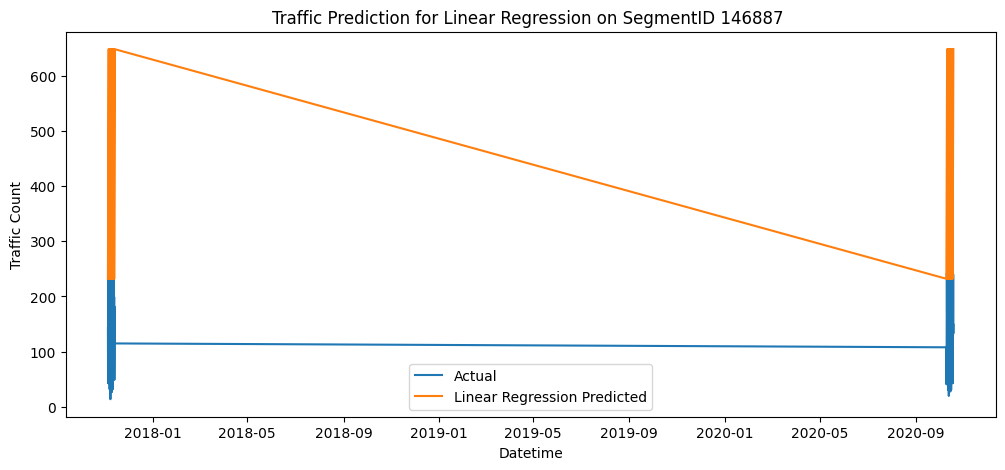

Baseline MSE for 25th hour prediction: 122455.19501253133


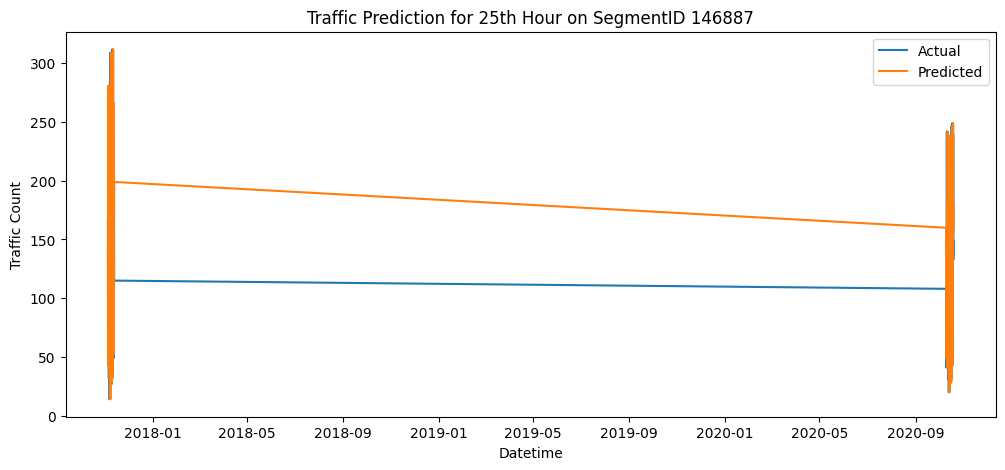

t-1 Hour Baseline MSE: 118838.45152889946


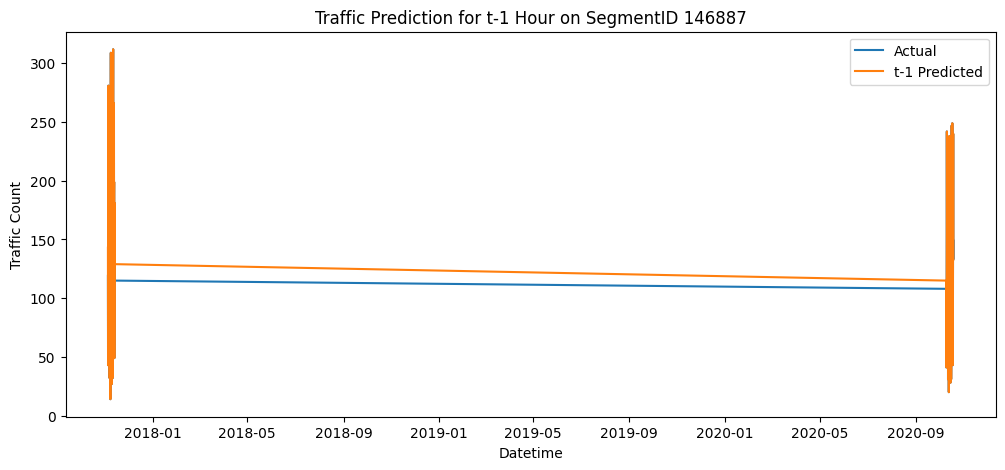

Global Average Baseline MSE: 456750.4785457696
                           MSE     RMSE      MAE     R²
Global Average      456750.479  675.833  384.464 -0.000
t-1 Hour Baseline   118838.452  344.730  142.557  0.740
t-24 Hour Baseline  122455.195  349.936  216.616  0.720
Linear Regression   440694.621  663.848  370.907  0.035


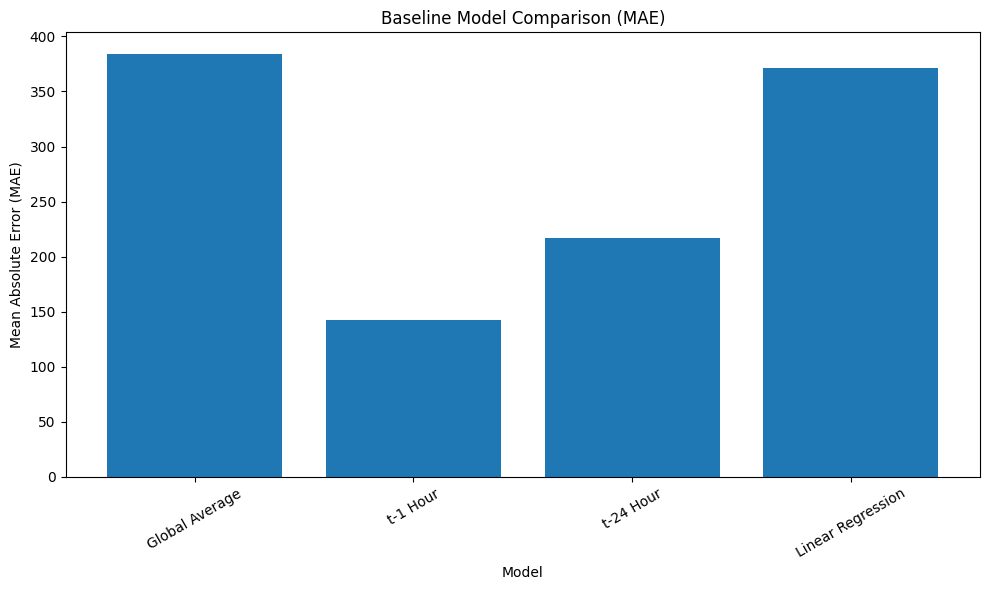

In [ ]:
# Baseline model, linear regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Starting with preparing to split
X = df_long[["Start_Hour"]]
y = df_long["Traffic_Count"]

# Still having weird issue with NAs that is appearing with this code
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
df_clean = df_long[mask]

# Splitting by SegmentID (street) to keep streets either in test or train, not both
segments = df_long["SegmentID"].unique()

train_segments, test_segments = train_test_split(segments, test_size=0.2, random_state=42)

print("Train segments:", len(train_segments))
print("Test segments:", len(test_segments))


# Extra precaution to avoid error
train_mask = df_clean["SegmentID"].isin(train_segments)
test_mask  = df_clean["SegmentID"].isin(test_segments)

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

# Now, data is split, so moving to the actual baseline model
#this is a linear regression model that is simply predicting by using time as a function
lr = LinearRegression()
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
baseline_mse = mean_squared_error(y_test, lr_pred)


print("Baseline Model MSE:", baseline_mse)

import matplotlib.pyplot as plt

# Plotting actual vs predicted
# Just making a copy to be safe bc I am adjusting the dataset slightly for best modeling
df_test = df_clean[test_mask].copy()
df_test["Predicted"] = lr_pred
df_test["Actual"] = y_test.values
# Big dataset, so just plotting a segment
first_seg = test_segments[0]
seg_df = df_test[df_test["SegmentID"] == first_seg]

# Creating a model representation
plt.figure(figsize=(12,5))
plt.plot(seg_df["Datetime"], seg_df["Actual"], label="Actual")
plt.plot(seg_df["Datetime"], seg_df["Predicted"], label="Linear Regression Predicted")
plt.xlabel("Datetime")
plt.ylabel("Traffic Count")
plt.title(f"Traffic Prediction for Linear Regression on SegmentID {first_seg} ")
plt.legend()
plt.show()


# Additional (more useful) baseline for predicting the 25th hour
# ie, predicting traffic for x time based on traffic at x time on the previous day

#Again, new version to be safe
df_clean = df_clean.sort_values(["SegmentID", "Datetime"]).copy()

#Since I want to predict the 25th hour, I am designating this here to account for the previous 24 hours
df_clean["Previous 24 Hours"] = df_clean.groupby("SegmentID")["Traffic_Count"].shift(24)
# Dropping nas just in case
df_hr = df_clean.dropna(subset=["Previous 24 Hours"])

# Since I am doing a new subset, must go through train/test
hr_train = df_hr[train_mask.loc[df_hr.index]]
hr_test  = df_hr[test_mask.loc[df_hr.index]]
y_test_hr = hr_test["Traffic_Count"]
hr_pred = hr_test["Previous 24 Hours"]
hr_mse = mean_squared_error(y_test_hr, hr_pred)

print("Baseline MSE for 25th hour prediction:", hr_mse)
seg_hr = hr_test[hr_test["SegmentID"] == first_seg]

plt.figure(figsize=(12,5))
plt.plot(seg_hr["Datetime"], seg_hr["Traffic_Count"], label="Actual")
plt.plot(seg_hr["Datetime"], seg_hr["Previous 24 Hours"], label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Traffic Count")
plt.title(f"Traffic Prediction for 25th Hour on SegmentID {first_seg}")
plt.legend()
plt.show()

# t-1 hour baseline, which is predicting the traffic at time t based on the previous hour t-1
df_clean = df_clean.sort_values(["SegmentID", "Datetime"])
df_clean["Prev_Hour"] = df_clean.groupby("SegmentID")["Traffic_Count"].shift(1)
df_t1 = df_clean.dropna(subset=["Prev_Hour"])
t1_test = df_t1[test_mask.loc[df_t1.index]]
y_test_t1 = t1_test["Traffic_Count"]
t1_pred   = t1_test["Prev_Hour"]
t1_mse = mean_squared_error(y_test_t1, t1_pred)

print("t-1 Hour Baseline MSE:", t1_mse)

seg_t1 = t1_test[t1_test["SegmentID"] == first_seg]

plt.figure(figsize=(12,5))
plt.plot(seg_t1["Datetime"], seg_t1["Traffic_Count"], label="Actual")
plt.plot(seg_t1["Datetime"], seg_t1["Prev_Hour"], label="t-1 Predicted")
plt.xlabel("Datetime")
plt.ylabel("Traffic Count")
plt.title(f"Traffic Prediction for t-1 Hour on SegmentID {first_seg}")
plt.legend()
plt.show()


# Global average baseline (predicts the same everywhere basically)

global_avg = df_clean[train_mask]["Traffic_Count"].mean()
global_pred = np.full(shape=len(y_test), fill_value=global_avg)

global_mse = mean_squared_error(y_test, global_pred)
print("Global Average Baseline MSE:", global_mse)

#gathering up
# Linear Regression
lr_y_true = y_test
lr_y_pred = lr_pred

# t-1 baseline
t1_y_true = y_test_t1
t1_y_pred = t1_pred

# t-24 baseline
hr_y_true = y_test_hr
hr_y_pred = hr_pred

# Global average baseline
global_y_true = y_test
global_y_pred = global_pred

from sklearn.metrics import mean_absolute_error, r2_score
#clean easy gathering of metrics
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2
results = {
    "Global Average": get_metrics(global_y_true, global_y_pred),
    "t-1 Hour Baseline": get_metrics(t1_y_true, t1_y_pred),
    "t-24 Hour Baseline": get_metrics(hr_y_true, hr_y_pred),
    "Linear Regression": get_metrics(lr_y_true, lr_y_pred)
}

#clean trable
results_df = pd.DataFrame(results, index=["MSE", "RMSE", "MAE", "R²"]).T
print(results_df.round(3))

#I originally plotted the RMSEs to comparte, but they are too similar so plotting MAEs instead

mae_values = [
    mean_absolute_error(global_y_true, global_y_pred),
    mean_absolute_error(t1_y_true, t1_y_pred),
    mean_absolute_error(hr_y_true, hr_y_pred),
    mean_absolute_error(lr_y_true, lr_y_pred)
]
model_names = [
    "Global Average",
    "t-1 Hour",
    "t-24 Hour",
    "Linear Regression"
]
plt.figure(figsize=(10,6))
plt.bar(model_names, mae_values)
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("Baseline Model Comparison (MAE)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [ ]:
# start training LSTM
# Sort dataframe
df_long = df_long.sort_values(["SegmentID", "Datetime"]).reset_index(drop=True)

# Add time features
df_long["HourOfDay"] = df_long["Datetime"].dt.hour
df_long["DayOfWeek"] = df_long["Datetime"].dt.weekday

# Global scaler ONLY for traffic
traffic_scaler = MinMaxScaler()
df_long["Traffic_Scaled"] = traffic_scaler.fit_transform(
    df_long["Traffic_Count"].values.reshape(-1,1)
)

features = ["Traffic_Scaled", "HourOfDay", "DayOfWeek"]
n_hours = 24

cut_time = df_long["Datetime"].quantile(0.80)

train_df = df_long[df_long["Datetime"] <= cut_time]
test_df  = df_long[df_long["Datetime"] >  cut_time]

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

def build_sequences(df):
    X, y = [], []

    for seg_id, group in df.groupby("SegmentID"):
        group = group.sort_values("Datetime")

        # Ensure no NaNs for this segment
        group = group.dropna(subset=features + ["Traffic_Scaled"])
        if len(group) <= n_hours:
            continue

        data = group[features].values
        target = group["Traffic_Scaled"].values

        for i in range(len(data) - n_hours):
            seq = data[i:i+n_hours]
            label = target[i+n_hours]

            # Skip ANY bad sequence
            if np.isnan(seq).any() or np.isnan(label):
                continue

            X.append(seq)
            y.append(label)

    return np.array(X), np.array(y)


X_train, y_train = build_sequences(train_df)
X_test,  y_test  = build_sequences(test_df)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train rows: 820922
Test rows : 205222
Train shape: (772836, 24, 3) (772836,)
Test shape : (185782, 24, 3) (185782,)


In [ ]:
print("Any NaN in X_train:", np.isnan(X_train).any())
print("Any NaN in y_train:", np.isnan(y_train).any())
print("Any Inf in X_train:", np.isinf(X_train).any())
print("Any Inf in y_train:", np.isinf(y_train).any())

print("X_train mean/max/min:", X_train.mean(), X_train.max(), X_train.min())
print("y_train mean/max/min:", y_train.mean(), y_train.max(), y_train.min())


Any NaN in X_train: False
Any NaN in y_train: False
Any Inf in X_train: False
Any Inf in y_train: False
X_train mean/max/min: 4.951004758987309 23.0 0.0
y_train mean/max/min: 0.04443801024614954 1.0 0.0


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Model
model = Sequential([
    LSTM(64, activation="tanh", input_shape=(n_hours, len(features))),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',      # track validation loss
    patience=3,              # stop after 3 epochs with no improvement
    restore_best_weights=True
)

# training
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# prediction
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 113s 6ms/step - loss: 7.4533e-04 - val_loss: 5.5708e-04
Epoch 2/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 118s 6ms/step - loss: 2.8396e-04 - val_loss: 5.0087e-04
Epoch 3/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 111s 6ms/step - loss: 2.3206e-04 - val_loss: 4.0595e-04
Epoch 4/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 111s 6ms/step - loss: 2.1276e-04 - val_loss: 3.9546e-04
Epoch 5/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 112s 6ms/step - loss: 1.9439e-04 - val_loss: 3.9665e-04
Epoch 6/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 141s 6ms/step - loss: 1.9356e-04 - val_loss: 3.4470e-04
Epoch 7/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 111s 6ms/step - loss: 1.7957e-04 - val_loss: 3.6824e-04
Epoch 8/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 112s 6ms/step - loss: 1.7136e-04 - val_loss: 3.3798e-04
Epoch 9/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 111s 6ms/step - loss: 1.7111e-04 - val_loss: 3.8150e-04
Epoch 10/20
19321/19321 ━━━━━━━━━━━━━━━━━━━━ 112s 6ms/step - loss: 1.6076e-04 - val_loss: 3.1657e-04

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Scaled metrics (will be between 0-1)
mse_scaled = mean_squared_error(y_test, y_pred)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred)
r2_scaled  = r2_score(y_test, y_pred)

print("Scaled metrics")
print("MSE (scaled) :", mse_scaled)
print("RMSE (scaled):", rmse_scaled)
print("MAE (scaled) :", mae_scaled)
print("R²  (scaled) :", r2_scaled)

# undo scaling
y_pred_unscaled = scaler.inverse_transform(y_pred)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1,1))

# vehicles/hour evaluation
mse_real = mean_squared_error(y_test_unscaled, y_pred_unscaled)
rmse_real = np.sqrt(mse_real)
mae_real = mean_absolute_error(y_test_unscaled, y_pred_unscaled)
r2_real  = r2_score(y_test_unscaled, y_pred_unscaled)

print("Unscaled metrics")
print("MSE (real) :", mse_real)
print("RMSE(real):", rmse_real)
print("MAE (real) :", mae_real)
print("R²  (real) :", r2_real)

Scaled metrics
MSE (scaled) : 6.483385289960669e-05
RMSE (scaled): 0.008051947149578584
MAE (scaled) : 0.004953712455618138
R²  (scaled) : 0.9342188273738914
Unscaled metrics
MSE (real) : 7191.567008727078
RMSE(real): 84.80310730584746
MAE (real) : 52.17249948302292
R²  (real) : 0.9342188274879403


                           MSE     RMSE      MAE     R²
Global Average      456750.479  675.833  384.464 -0.000
Linear Regression   440694.621  663.848  370.907  0.035
t-24 Hour Baseline  122455.195  349.936  216.616  0.720
t-1 Hour Baseline   118838.452  344.730  142.557  0.740
LSTM                  7191.567   84.803   52.172  0.934


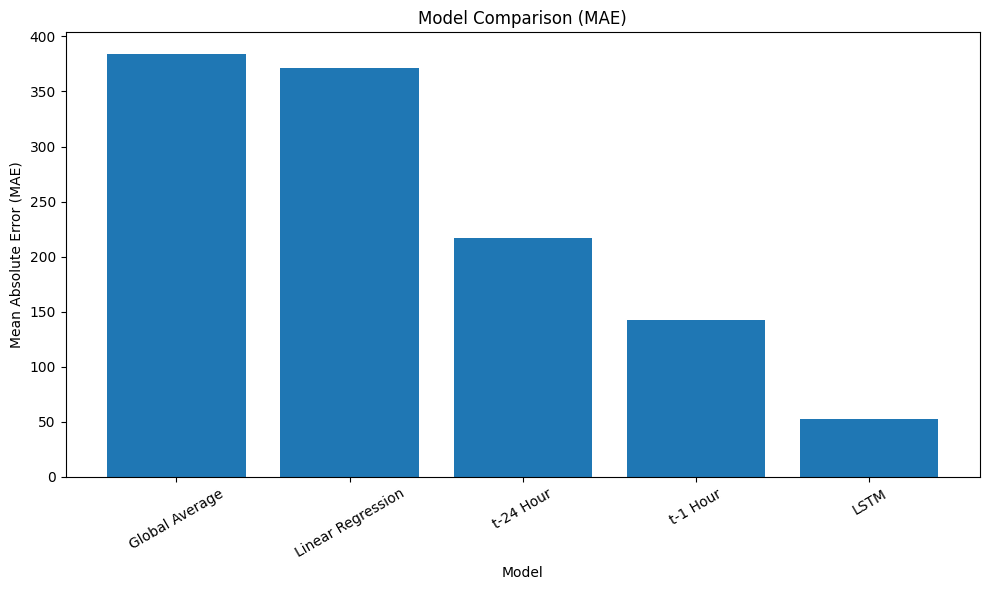

In [138]:
# Comparing baseline models to our actual models
results = {
    "Global Average": get_metrics(global_y_true, global_y_pred),
    "Linear Regression": get_metrics(lr_y_true,lr_y_pred),
    "t-24 Hour Baseline": get_metrics(hr_y_true,hr_y_pred),
    "t-1 Hour Baseline": get_metrics(t1_y_true, t1_y_pred),
    "LSTM": (mse_real,rmse_real, mae_real,r2_real)
}
results_df = pd.DataFrame(results, index=["MSE", "RMSE", "MAE", "R²"]).T
print(results_df.round(3))

mae_values = [
    mean_absolute_error(global_y_true, global_y_pred),
    mean_absolute_error(lr_y_true, lr_y_pred),
    mean_absolute_error(hr_y_true, hr_y_pred),
    mean_absolute_error(t1_y_true, t1_y_pred),
    mae_real
]

model_names = [
    "Global Average",
    "Linear Regression",
    "t-24 Hour",
    "t-1 Hour",
    "LSTM"
]
plt.figure(figsize=(10,6))
plt.bar(model_names, mae_values)
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
def predict_next_hour(segment_id):
    """
    Predicts the next hour of traffic for any segment in the dataset.
    Automatically scales using the last 24 hours of that segment.
    (help from chat)
    """
    group = df_long[df_long["SegmentID"] == segment_id].sort_values("Datetime")

    if len(group) < n_hours:
        raise ValueError("Not enough data for this segment.")

    last_24 = group[features].values[-n_hours:].reshape(1, n_hours, 3)

    scaled_pred = model.predict(last_24)[0][0]
    real_pred = traffic_scaler.inverse_transform([[scaled_pred]])[0][0]

    print(f"Next hour prediction for {segment_id}: {real_pred:.2f}")
    return real_pred

In [ ]:
predict_next_hour(15540) # beach street, less occupied street
predict_next_hour(32329) # canal street, pretty congested street in new york

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Next hour prediction for 15540: 56.02
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Next hour prediction for 32329: 666.81


np.float64(666.8076498806477)

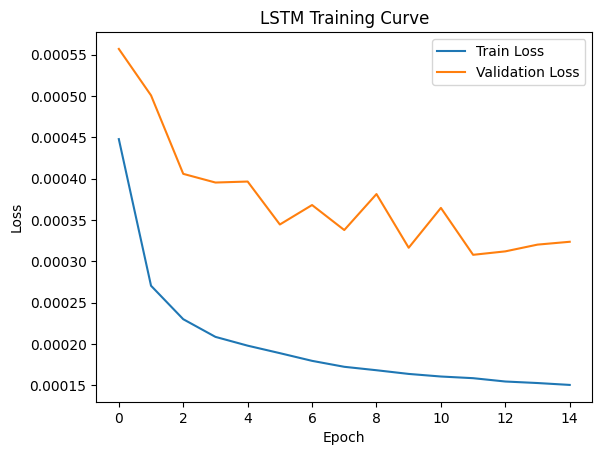

In [ ]:
# loss curves
from matplotlib import pyplot as plt
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM Training Curve")
plt.show()

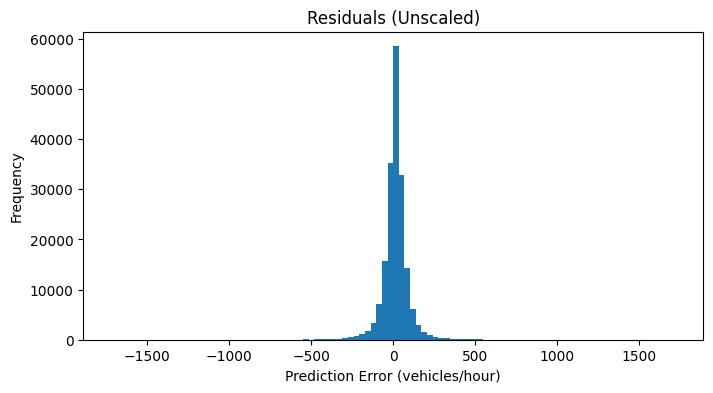

In [ ]:
errors_real = (y_pred_unscaled.flatten() - y_test_unscaled.flatten())

plt.figure(figsize=(8,4))
plt.hist(errors_real, bins=100)
plt.xlabel("Prediction Error (vehicles/hour)")
plt.ylabel("Frequency")
plt.title("Residuals (Unscaled)")
plt.show()

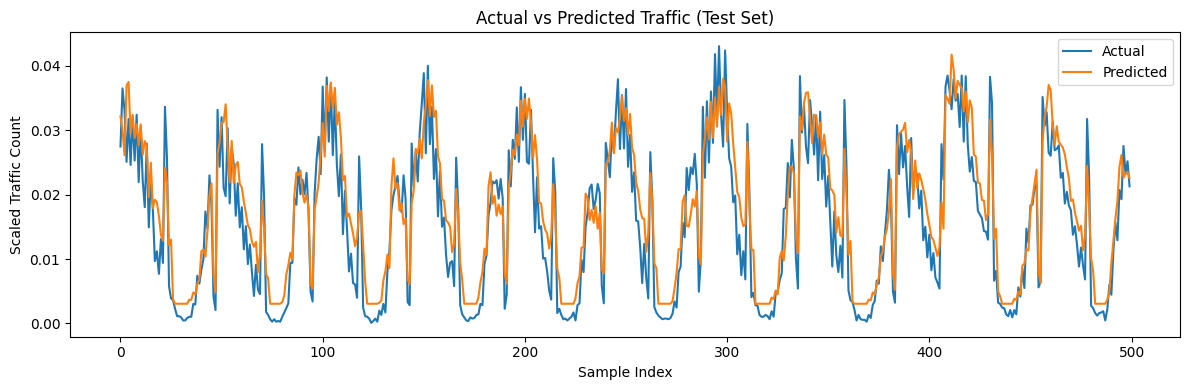

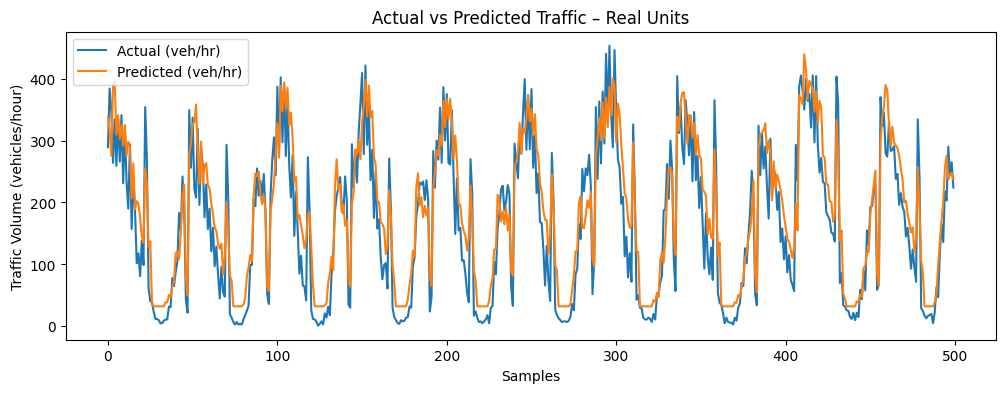

In [ ]:
# actual vs predicted
n = 500
y_true_plot = y_test[:n]
y_pred_plot = y_pred[:n].flatten()

plt.figure(figsize=(12,4))
plt.plot(y_true_plot, label="Actual")
plt.plot(y_pred_plot, label="Predicted")
plt.title("Actual vs Predicted Traffic (Test Set)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Traffic Count")
plt.legend()
plt.tight_layout()
plt.show()

# unscaled traffic count
y_true_real = y_test_unscaled[:n]
y_pred_real = y_pred_unscaled[:n]

plt.figure(figsize=(12,4))
plt.plot(y_true_real, label="Actual (veh/hr)")
plt.plot(y_pred_real, label="Predicted (veh/hr)")
plt.xlabel("Samples")
plt.ylabel("Traffic Volume (vehicles/hour)")
plt.title("Actual vs Predicted Traffic – Real Units")
plt.legend()
plt.show()


In [ ]:
def predict_next_24_hours(segment_id):

    group = df_long[df_long["SegmentID"] == segment_id].sort_values("Datetime")

    if len(group) < n_hours:
        raise ValueError("Not enough data.")

    window = group[features].values[-n_hours:].tolist()
    preds_scaled = []

    last_time = group["Datetime"].iloc[-1]

    for _ in range(24):

        X_input = np.array(window[-n_hours:]).reshape(1, n_hours, 3)
        next_scaled = model.predict(X_input)[0][0]
        preds_scaled.append(next_scaled)

        # Time features for next hour
        last_time += pd.Timedelta(hours=1)
        next_hour = last_time.hour
        next_day  = last_time.weekday()

        # Add predicted step
        window.append([next_scaled, next_hour, next_day])

    preds_real = traffic_scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1,1)
    ).flatten()

    future_times = [group["Datetime"].iloc[-1] + pd.Timedelta(hours=i+1) for i in range(24)]

    return pd.DataFrame({
        "Datetime": future_times,
        "Predicted_Traffic": preds_real
    })

In [ ]:
predict_next_24_hours(32329) # canal street

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


,Datetime,Predicted_Traffic
0,2019-10-14 00:00:00,666.807678
1,2019-10-14 01:00:00,452.023315
2,2019-10-14 02:00:00,444.423431
3,2019-10-14 03:00:00,414.666809
4,2019-10-14 04:00:00,413.942078
5,2019-10-14 05:00:00,421.749207
6,2019-10-14 06:00:00,682.969910
7,2019-10-14 07:00:00,975.479675
8,2019-10-14 08:00:00,1041.928955
9,2019-10-14 09:00:00,974.131287


In [ ]:
predict_next_24_hours(15540)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


,Datetime,Predicted_Traffic
0,2019-09-30 00:00:00,56.021172
1,2019-09-30 01:00:00,59.879616
2,2019-09-30 02:00:00,47.428665
3,2019-09-30 03:00:00,64.144226
4,2019-09-30 04:00:00,53.723019
5,2019-09-30 05:00:00,47.700573
6,2019-09-30 06:00:00,209.452591
7,2019-09-30 07:00:00,450.343994
8,2019-09-30 08:00:00,501.803375
9,2019-09-30 09:00:00,411.676270
